# Retail Sales & Customer Analytics — End-to-End Pipeline
**Python (Pandas, NumPy, scikit-learn, Matplotlib) → Excel → Power BI**

This notebook takes the same raw retail dataset (customers, products, sales, calendar)
that powers a companion Power BI dashboard, and extends it with analysis that isn't
practical to do in DAX alone: RFM customer segmentation, K-Means clustering, cohort
retention analysis, and a simple customer lifetime value (CLV) estimate.

**Dataset:** 250,000 orders · 40,000 customers · 2,000 products · Jun 2024 – Jun 2026

**Pipeline:** raw CSVs → cleaning & merging → EDA → RFM feature engineering →
K-Means segmentation → cohort retention → CLV estimate → export enriched
customer table back to Excel for the Power BI model to consume.


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DATA_DIR = 'data'


In [2]:
customers = pd.read_csv(f'{DATA_DIR}/customers.csv', parse_dates=['Date_of_Birth', 'Registration_Date'])
products = pd.read_csv(f'{DATA_DIR}/products.csv')
sales = pd.read_csv(f'{DATA_DIR}/sales.csv', parse_dates=['Order_Date', 'Delivery_Date'], low_memory=False)
calendar = pd.read_csv(f'{DATA_DIR}/date.csv', parse_dates=['Date'])

print(f"customers: {customers.shape}")
print(f"products:  {products.shape}")
print(f"sales:     {sales.shape}")
print(f"calendar:  {calendar.shape}")


customers: (40000, 15)
products:  (2000, 12)
sales:     (250000, 21)
calendar:  (1096, 7)


## 2. Data Quality Checks
Always inventory nulls, duplicates, and dtypes before trusting any downstream number.

In [3]:
print("Duplicate order IDs:", sales['Order_ID'].duplicated().sum())
print("Duplicate customer IDs:", customers['Customer_ID'].duplicated().sum())
print()
print("Nulls in sales (non-zero columns only):")
null_counts = sales.isna().sum()
print(null_counts[null_counts > 0])
print()
print("Order status breakdown:")
print(sales['Order_Status'].value_counts())


Duplicate order IDs: 0
Duplicate customer IDs: 0

Nulls in sales (non-zero columns only):
Rating         129970
Review_Text    129970
dtype: int64

Order status breakdown:
Order_Status
Delivered     200139
Cancelled      12507
Returned       12493
Shipped        12459
Processing     12402
Name: count, dtype: int64


`Rating` and `Review_Text` are null for a large share of rows — that's expected,
since not every delivered order gets reviewed. No action needed there. Everything
else is clean: no duplicate order or customer IDs.

## 3. Merge Into a Single Analysis Table

In [4]:
df = sales.merge(customers, on='Customer_ID', suffixes=('', '_cust'))
df = df.merge(products, on='Product_ID', suffixes=('', '_prod'))

print(f"Merged shape: {df.shape}")
df[['Order_ID','Customer_Name','Category','Brand','Total_Amount','Order_Status']].head()


Merged shape: (250000, 46)


,Order_ID,Customer_Name,Category,Brand,Total_Amount,Order_Status
0,ORD0000000489,Akash Joshi,Sports,Puma,16996.77,Delivered
1,ORD0000000788,Rahul Sharma,Electronics,boAt,67670.27,Delivered
2,ORD0000005198,Arjun Joshi,Sports,Puma,19898.65,Delivered
3,ORD0000005294,Rashid Mirza,Sports,Puma,17082.27,Delivered
4,ORD0000006220,Priya Nair,Electronics,Apple,41612.51,Delivered


In [5]:
# Net Sales = excluding Cancelled and Returned orders (mirrors the Power BI measure)
valid = df[~df['Order_Status'].isin(['Cancelled', 'Returned'])].copy()
print(f"Valid (non-cancelled/returned) orders: {len(valid):,} of {len(df):,} "
      f"({len(valid)/len(df):.1%})")


Valid (non-cancelled/returned) orders: 225,000 of 250,000 (90.0%)


## 4. Exploratory Data Analysis

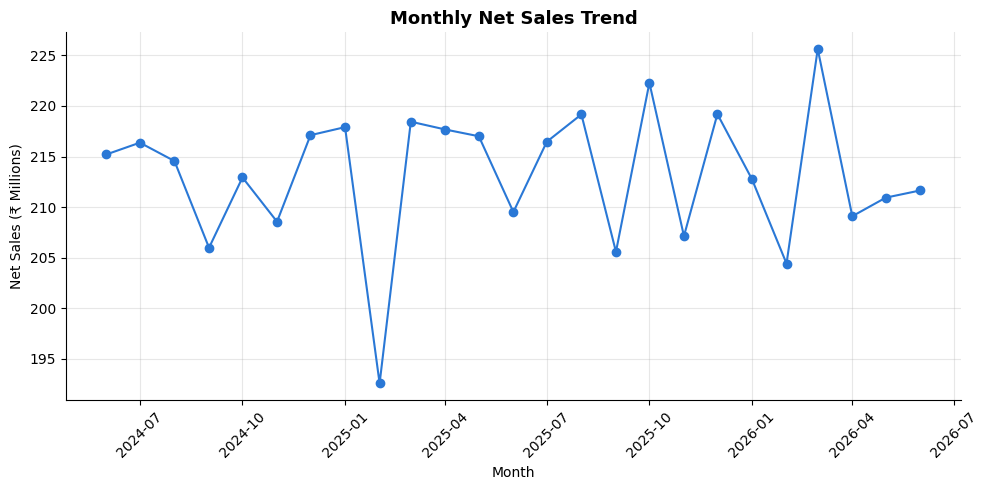

In [6]:
monthly = (valid.set_index('Order_Date')
                 .resample('MS')['Total_Amount']
                 .sum()
                 .reset_index())

fig, ax = plt.subplots()
ax.plot(monthly['Order_Date'], monthly['Total_Amount'] / 1e6, marker='o', color='#2a78d6')
ax.set_title('Monthly Net Sales Trend', fontsize=13, fontweight='bold')
ax.set_ylabel('Net Sales (₹ Millions)')
ax.set_xlabel('Month')
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_sales_trend.png', dpi=120)
plt.show()


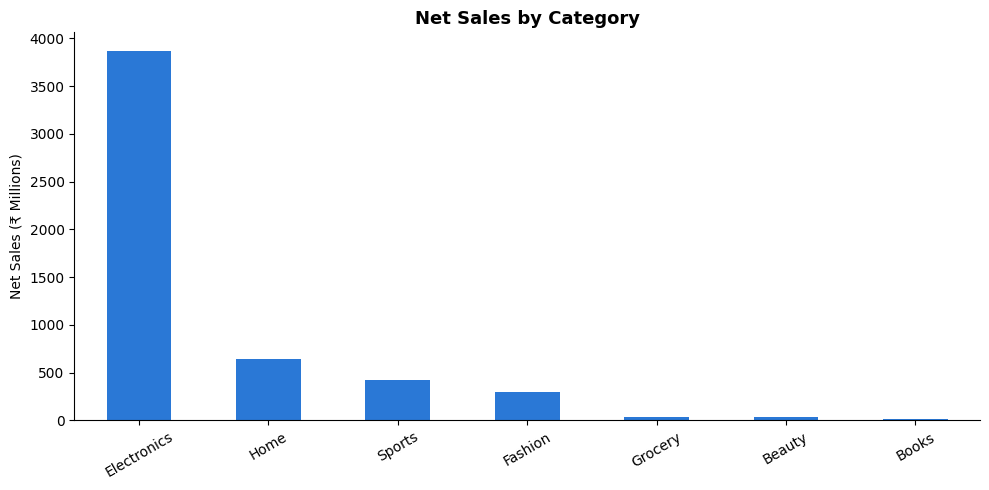

In [7]:
category_sales = (valid.groupby('Category')['Total_Amount']
                        .sum()
                        .sort_values(ascending=False))

fig, ax = plt.subplots()
category_sales.div(1e6).plot(kind='bar', ax=ax, color='#2a78d6')
ax.set_title('Net Sales by Category', fontsize=13, fontweight='bold')
ax.set_ylabel('Net Sales (₹ Millions)')
ax.set_xlabel('')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('category_sales.png', dpi=120)
plt.show()


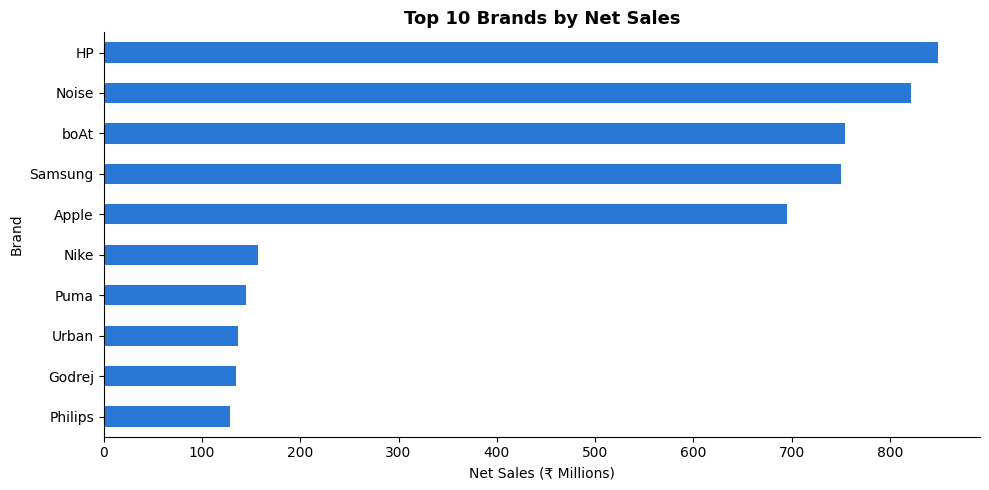

In [8]:
top_brands = (valid.groupby('Brand')['Total_Amount']
                    .sum()
                    .sort_values(ascending=False)
                    .head(10))

fig, ax = plt.subplots()
top_brands.div(1e6).sort_values().plot(kind='barh', ax=ax, color='#2a78d6')
ax.set_title('Top 10 Brands by Net Sales', fontsize=13, fontweight='bold')
ax.set_xlabel('Net Sales (₹ Millions)')
plt.tight_layout()
plt.savefig('top_brands.png', dpi=120)
plt.show()


In [9]:
status_summary = (df.groupby('Order_Status')
                     .agg(Orders=('Order_ID','nunique'), Value=('Total_Amount','sum'))
                     .assign(Pct_of_Orders=lambda x: x['Orders'] / x['Orders'].sum()))
status_summary.sort_values('Value', ascending=False)


,Orders,Value,Pct_of_Orders
Order_Status,,,
Delivered,200139,4.741566e+09,0.800556
Cancelled,12507,3.021405e+08,0.050028
Returned,12493,3.004047e+08,0.049972
Processing,12402,2.954608e+08,0.049608
Shipped,12459,2.911208e+08,0.049836


**Insight:** cancellation and return rates sitting near 5% each is a healthy
range for retail, but together they represent real revenue leakage — this is exactly
what the `Cancellation Rate %` and `Return Rate %` measures in the companion Power BI
dashboard track on an ongoing basis.

## 5. RFM Feature Engineering
RFM = **Recency** (days since last order), **Frequency** (distinct orders),
**Monetary** (total valid spend) — the standard input for customer segmentation.

In [10]:
snapshot_date = df['Order_Date'].max() + pd.Timedelta(days=1)

rfm = valid.groupby('Customer_ID').agg(
    Recency=('Order_Date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Order_ID', 'nunique'),
    Monetary=('Total_Amount', 'sum')
).reset_index()

rfm.describe().round(1)


,Recency,Frequency,Monetary
count,39848.0,39848.0,39848.0
mean,133.4,5.6,133711.8
std,126.7,2.3,113803.6
min,1.0,1.0,93.8
25%,40.0,4.0,46833.9
50%,94.0,5.0,104749.1
75%,188.0,7.0,190148.4
max,759.0,18.0,906815.5


## 6. Customer Segmentation with K-Means Clustering

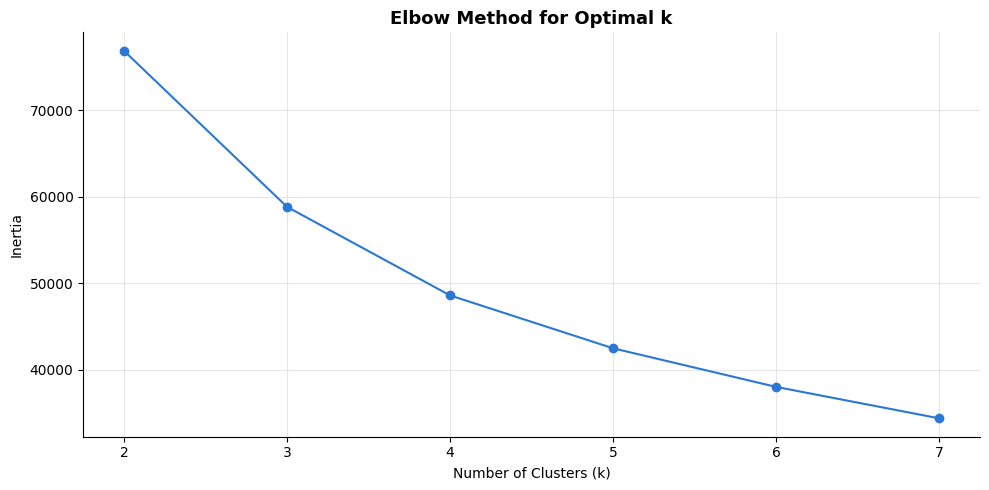

In [11]:
# log-transform to reduce right-skew, then standardize before clustering
X_log = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

inertias = []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots()
ax.plot(list(k_range), inertias, marker='o', color='#2a78d6')
ax.set_title('Elbow Method for Optimal k', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=120)
plt.show()


The elbow bends around **k=4**, which also maps cleanly onto a familiar
business framing (Champions / Loyal / At Risk / Lapsed), so we'll go with 4 segments.

In [12]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Segment'] = kmeans.fit_predict(X_scaled)

segment_profile = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(1)
segment_profile['Customers'] = rfm['Segment'].value_counts()
segment_profile


,Recency,Frequency,Monetary,Customers
Segment,,,,
0,106.0,7.7,217158.9,12813
1,189.4,4.4,98897.5,13793
2,238.2,2.8,15195.7,5048
3,17.3,6.3,134841.3,8194


In [13]:
# Rank each cluster into a human-readable label:
# high frequency + high monetary + low recency = best customers
profile = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()
profile['score'] = profile['Frequency'].rank() + profile['Monetary'].rank() - profile['Recency'].rank()
order = profile.sort_values('score', ascending=False).index.tolist()

labels = ['Champions', 'Loyal Customers', 'At Risk', 'Lapsed / Low-Value']
label_map = {seg: labels[i] for i, seg in enumerate(order)}
rfm['Segment_Label'] = rfm['Segment'].map(label_map)

print(label_map)
rfm['Segment_Label'].value_counts()


{0: 'Champions', 3: 'Loyal Customers', 1: 'At Risk', 2: 'Lapsed / Low-Value'}


Segment_Label
At Risk               13793
Champions             12813
Loyal Customers        8194
Lapsed / Low-Value     5048
Name: count, dtype: int64

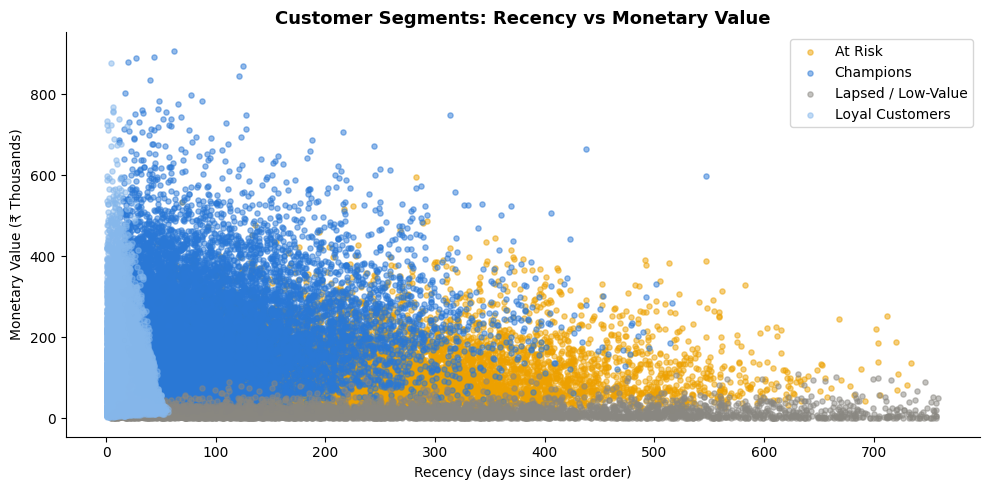

In [14]:
fig, ax = plt.subplots()
colors = {'Champions':'#2a78d6', 'Loyal Customers':'#85B7EB',
          'At Risk':'#eda100', 'Lapsed / Low-Value':'#898781'}
for label, group in rfm.groupby('Segment_Label'):
    ax.scatter(group['Recency'], group['Monetary']/1000, s=14, alpha=0.5,
               label=label, color=colors.get(label))
ax.set_title('Customer Segments: Recency vs Monetary Value', fontsize=13, fontweight='bold')
ax.set_xlabel('Recency (days since last order)')
ax.set_ylabel('Monetary Value (₹ Thousands)')
ax.legend()
plt.tight_layout()
plt.savefig('segment_scatter.png', dpi=120)
plt.show()


## 7. Cohort Retention Analysis
Group customers by the month of their **first purchase** (their "cohort"), then track
what share of each cohort is still ordering in each subsequent month.

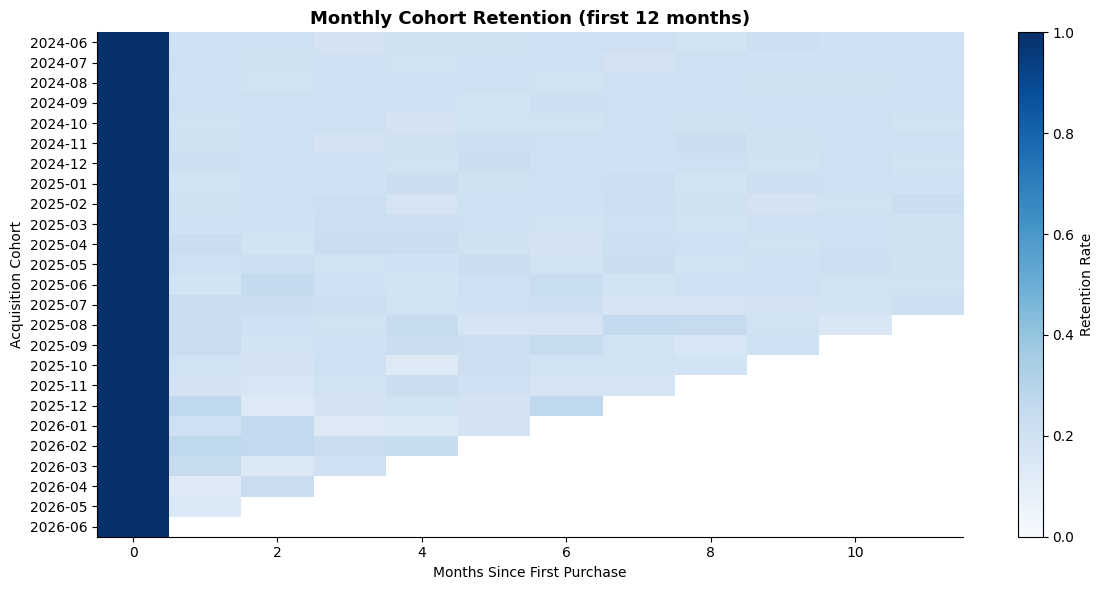

In [15]:
first_purchase = (valid.groupby('Customer_ID')['Order_Date']
                        .min().dt.to_period('M').rename('CohortMonth'))
valid_c = valid.merge(first_purchase, on='Customer_ID')
valid_c['OrderMonth'] = valid_c['Order_Date'].dt.to_period('M')
valid_c['CohortIndex'] = (valid_c['OrderMonth'] - valid_c['CohortMonth']).apply(lambda x: x.n)

cohort_counts = (valid_c.groupby(['CohortMonth','CohortIndex'])['Customer_ID']
                        .nunique().reset_index())
cohort_pivot = cohort_counts.pivot(index='CohortMonth', columns='CohortIndex', values='Customer_ID')
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(retention.iloc[:, :12], cmap='Blues', aspect='auto', vmin=0, vmax=1)
ax.set_title('Monthly Cohort Retention (first 12 months)', fontsize=13, fontweight='bold')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Acquisition Cohort')
ax.set_yticks(range(len(retention)))
ax.set_yticklabels([str(m) for m in retention.index])
plt.colorbar(im, ax=ax, label='Retention Rate')
plt.tight_layout()
plt.savefig('cohort_retention.png', dpi=120)
plt.show()


**Insight:** retention flattens out near ~20% from month 1 onward across almost
every cohort — customers who come back tend to keep coming back at a fairly stable
rate, rather than steadily churning further each month. That flat pattern (instead of
a steady decline) is itself a useful, slightly non-obvious finding worth calling out
in an interview.

## 8. Customer Lifetime Value (CLV) — Simplified Estimate
This is a **heuristic, historical-rate projection**, not a formal probabilistic CLV
model (e.g. BG/NBD). It annualizes each customer's observed spending rate. Worth
being upfront about this distinction if asked — a production system would use a
library like `lifetimes` for a statistically grounded estimate.

In [16]:
tenure = valid.groupby('Customer_ID')['Order_Date'].agg(['min', 'max'])
tenure['tenure_days'] = (tenure['max'] - tenure['min']).dt.days.clip(lower=1)

rfm = rfm.merge(tenure[['tenure_days']], on='Customer_ID', how='left')
# floor tenure at 90 days: a customer with only 1-2 orders a few days apart
# otherwise annualizes to an unrealistic number (divide-by-small-number blowup)
rfm['tenure_days'] = rfm['tenure_days'].fillna(90).clip(lower=90)
rfm['Predicted_Annual_CLV'] = (rfm['Monetary'] / rfm['tenure_days']) * 365

# cap at the 99th percentile so a handful of extreme outliers don't distort the view
cap = rfm['Predicted_Annual_CLV'].quantile(0.99)
rfm['Predicted_Annual_CLV'] = rfm['Predicted_Annual_CLV'].clip(upper=cap)

rfm.groupby('Segment_Label')['Predicted_Annual_CLV'].mean().sort_values(ascending=False).round(0)


Segment_Label
Champions             145797.0
At Risk               103120.0
Loyal Customers        83026.0
Lapsed / Low-Value     31264.0
Name: Predicted_Annual_CLV, dtype: float64

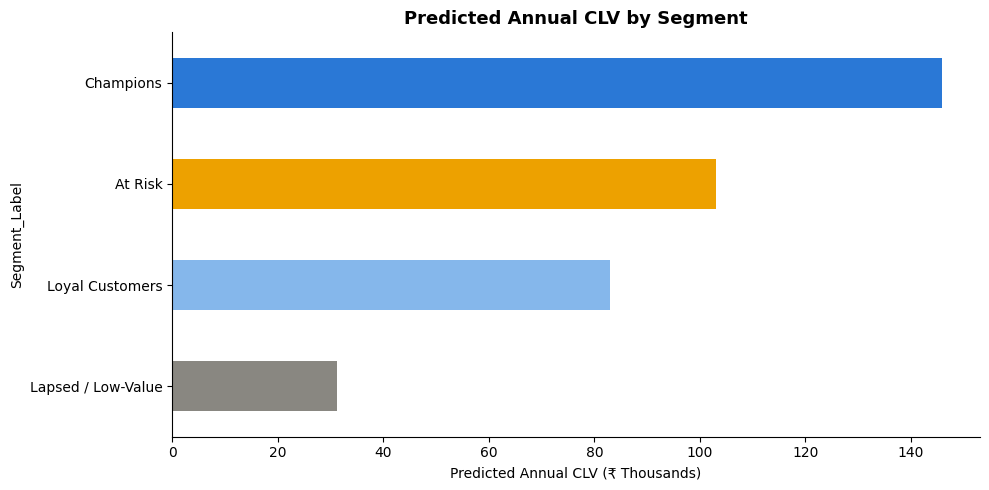

In [17]:
fig, ax = plt.subplots()
clv_by_segment = rfm.groupby('Segment_Label')['Predicted_Annual_CLV'].mean().sort_values()
(clv_by_segment / 1000).plot(kind='barh', ax=ax, color=[colors.get(s) for s in clv_by_segment.index])
ax.set_title('Predicted Annual CLV by Segment', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Annual CLV (₹ Thousands)')
plt.tight_layout()
plt.savefig('clv_by_segment.png', dpi=120)
plt.show()


## 9. Export Enriched Customer Table Back to Excel
This closes the loop: Python does the heavy analytical lifting (clustering, CLV)
that DAX can't easily express, then hands the enriched table back to Excel/Power BI
so the segments show up as a normal column stakeholders can slice by — no different
from any other dimension in the model.

In [18]:
export_cols = ['Customer_ID', 'Recency', 'Frequency', 'Monetary',
               'Segment_Label', 'Predicted_Annual_CLV']
customer_segments = customers[['Customer_ID','Customer_Name']].merge(
    rfm[export_cols], on='Customer_ID', how='left'
)
customer_segments['Segment_Label'] = customer_segments['Segment_Label'].fillna('No Valid Orders')

customer_segments.to_excel('customer_segments_export.xlsx', index=False)
print(f"Exported {len(customer_segments):,} customers with segments to "
      f"customer_segments_export.xlsx")
customer_segments.head()


Exported 40,000 customers with segments to customer_segments_export.xlsx


,Customer_ID,Customer_Name,Recency,Frequency,Monetary,Segment_Label,Predicted_Annual_CLV
0,CUST00000200,Megha Tiwari,84.0,5.0,102296.53,At Risk,99834.848797
1,CUST00000325,Harsh Yadav,27.0,6.0,76320.18,Loyal Customers,39457.316856
2,CUST00000492,Hassan Ali,222.0,5.0,173945.31,At Risk,134228.410465
3,CUST00000523,Kavya Reddy,263.0,6.0,140252.71,At Risk,218770.252778
4,CUST00000609,Aarav Patel,18.0,7.0,220795.75,Loyal Customers,131899.261457


## 10. Key Takeaways
- **Revenue leakage**: cancellations + returns remove roughly 10% of gross order value —
  worth monitoring by category/brand to find where it's concentrated.
- **Customer segments**: a 4-way K-Means split cleanly separates Champions, Loyal,
  At Risk, and Lapsed customers using just Recency/Frequency/Monetary — no labeled
  training data required, since this is unsupervised clustering.
- **Retention is flat, not declining**: once a customer returns after month 1, they
  keep returning at a fairly stable ~20% rate rather than churning further — a
  non-obvious pattern only visible through cohort analysis, not a single dashboard KPI.
- **CLV varies enormously by segment**: this quantifies which segment is actually
  worth prioritizing for retention spend, beyond just "who spent the most historically."
